In [7]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd


def preparar_dataset_cancer():
    file_data = "breast-cancer-wisconsin.data"  # Path to local dataset

    # Column names
    columns = ["ID", "Clump_Thickness", "Uniformity_Cell_Size", "Uniformity_Cell_Shape", 
            "Marginal_Adhesion", "Single_Epithelial_Cell_Size", "Bare_Nuclei", 
            "Bland_Chromatin", "Normal_Nucleoli", "Mitoses", "Class"]

    # Read dataset
    df = pd.read_csv(file_data, names=columns, header=None, na_values="?")

    # Drop rows with missing values
    df.dropna(inplace=True)

    # Convert to appropriate types
    df["Bare_Nuclei"] = df["Bare_Nuclei"].astype(int)
    df["Class"] = df["Class"].replace({2: 1, 4: 0}) # 1 = benign, 0 = malignant

    # Remove ID column (not useful for ML)
    df.drop(columns=["ID"], inplace=True)


    # Separate features and labels
    X = df.drop(columns=["Class"])
    y = df["Class"].values
    col_names = X.columns
    
    scaler = MinMaxScaler()
    X = scaler.fit_transform(X)
    return X,y,col_names

In [8]:
X,y,col_names = preparar_dataset_cancer()

<h1>Logistic Regression</h1>

In [9]:
from LogisticRegressionDRO import LogisticRegressionDRO
prueba = LogisticRegressionDRO(X,y)
prueba.fit()


<h2>p=1</h2>

In [13]:
a= prueba.percentile(20)
l=[]
from tqdm import tqdm
import numpy as np
lis = list(np.arange(0, 100, 1))
anterior = 0
g=[]
for i in tqdm(lis):
    sin = prueba.search(a,p=1,eps=i,theta=0)
    con = prueba.search(a,p=1,eps=i,theta=100000)
    if (not np.array_equal(sin,con)) and (not np.array_equal(con,anterior)):
        l.append(i)
        anterior=con
        print("hola")
        g.append(sin-con)

100%|██████████| 100/100 [01:23<00:00,  1.20it/s]


In [14]:
print(l)

[]


100%|██████████| 5/5 [00:11<00:00,  2.32s/it]


PERCENTILES CALCULADOS


  0%|          | 0/5 [00:00<?, ?it/s]

CALCULO DEL CONTRAFACTICO DE UN NUEVO INDIVIDUO


CALCULAMOS CON UN NUEVO EPSILON
CASO SIN INCERTIDUMBRE CALCULADO


...

CASO CON INCERTIDUMBRE CALCULADO
CALCULAMOS CON UN NUEVO EPSILON
CASO SIN INCERTIDUMBRE CALCULADO


CASO CON INCERTIDUMBRE CALCULADO
CALCULAMOS CON UN NUEVO EPSILON
CASO SIN INCERTIDUMBRE CALCULADO


CASO CON INCERTIDUMBRE CALCULADO
CALCULAMOS CON UN NUEVO EPSILON
CASO SIN INCERTIDUMBRE CALCULADO


100%|██████████| 5/5 [02:21<00:00, 28.21s/it]

CASO CON INCERTIDUMBRE CALCULADO


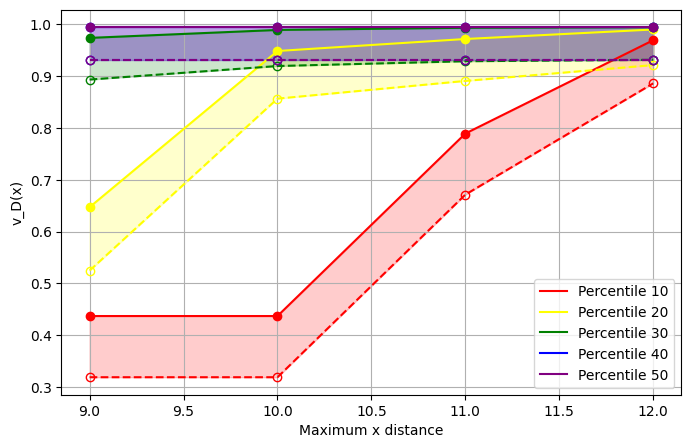

In [ ]:
prueba.plotPareto(p=1,epsList=[9,9.5,10,10.5,11,12],highTheta=0.5)

  0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [00:08<00:00,  1.68s/it]


PERCENTILES CALCULADOS


  0%|          | 0/5 [00:00<?, ?it/s]

CALCULO DEL CONTRAFACTICO DE UN NUEVO INDIVIDUO


...

CASO CON INCERTIDUMBRE CALCULADO
CALCULAMOS CON UN NUEVO EPSILON
CASO SIN INCERTIDUMBRE CALCULADO


CASO CON INCERTIDUMBRE CALCULADO
CALCULAMOS CON UN NUEVO EPSILON
CASO SIN INCERTIDUMBRE CALCULADO


CASO CON INCERTIDUMBRE CALCULADO
CALCULAMOS CON UN NUEVO EPSILON
CASO SIN INCERTIDUMBRE CALCULADO


100%|██████████| 5/5 [00:31<00:00,  6.29s/it]

CASO CON INCERTIDUMBRE CALCULADO


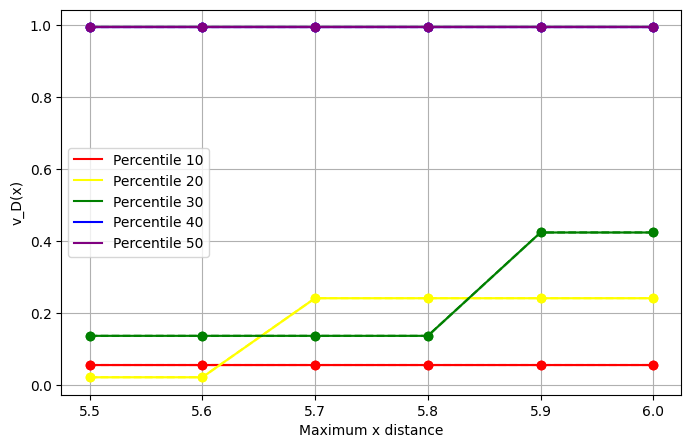

In [6]:
prueba.plotParetoNominal(p=1,epsList=[5.5,5.6,5.7,5.8,5.9,6],highTheta=100)

In [ ]:
prueba.plotPareto(p=1,epsList=[11.2,10.7,10.3],highTheta=0)

<h2>p=2</h2>

In [60]:
a= prueba.percentile(20)
l=[]
from tqdm import tqdm
import numpy as np
lis = list(np.arange(20, 50, 1))
anterior = 0
g=[]
for i in tqdm(lis):
    sin = prueba.search(a,p=2,eps=i,theta=0)
    con = prueba.search(a,p=2,eps=i,theta=1000000000)
    if (not np.array_equal(sin,con)) and (not np.array_equal(con,anterior)):
        l.append(i)
        anterior=con
        print("hola")
        g.append(sin-con)

100%|██████████| 30/30 [01:45<00:00,  3.51s/it]


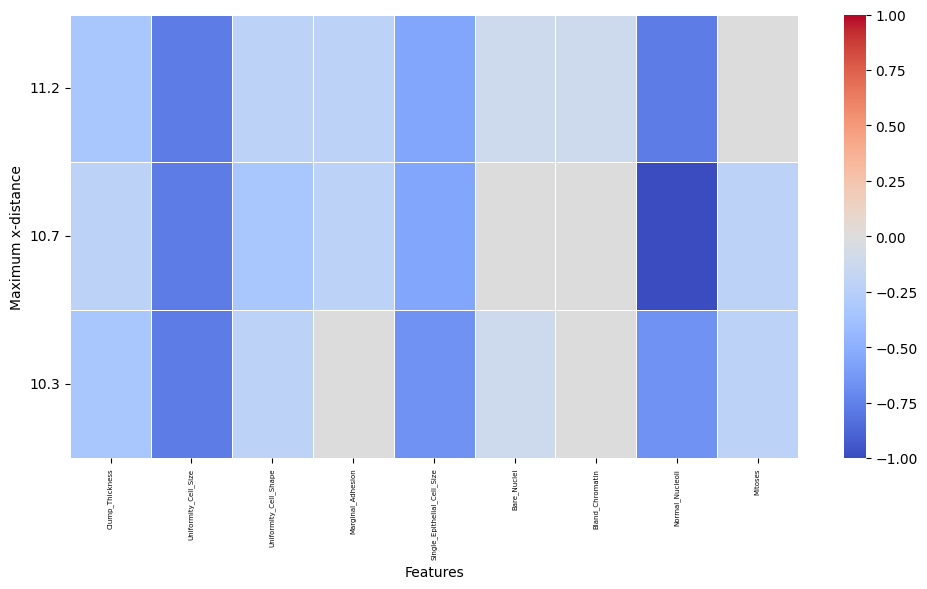

In [14]:
prueba.plot_heatmap(col_labels=col_names,epsList=[11.2,10.7,10.3],p=2,theta=1000)

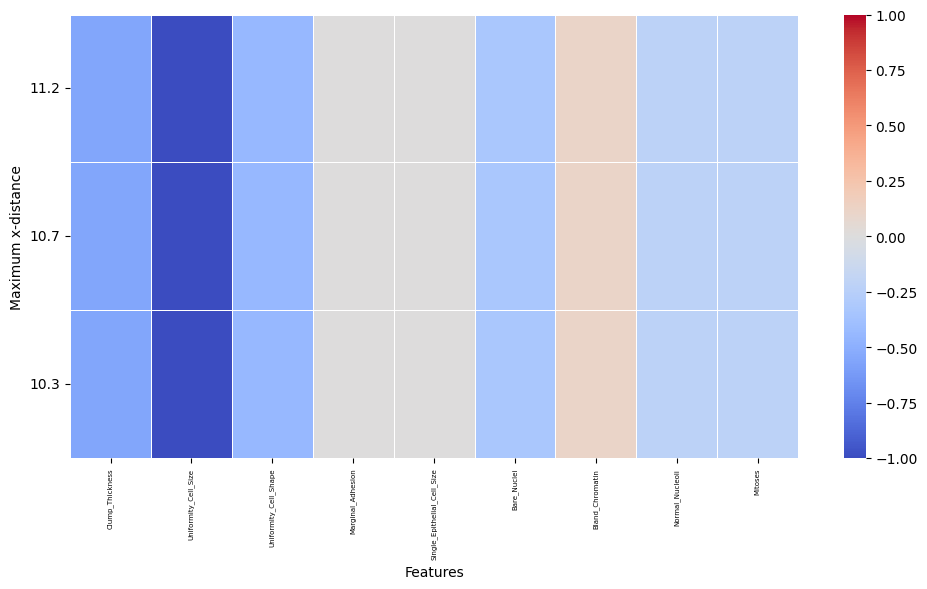

In [15]:
prueba.plot_heatmap(col_labels=col_names,epsList=[11.2,10.7,10.3],p=2,theta=0)

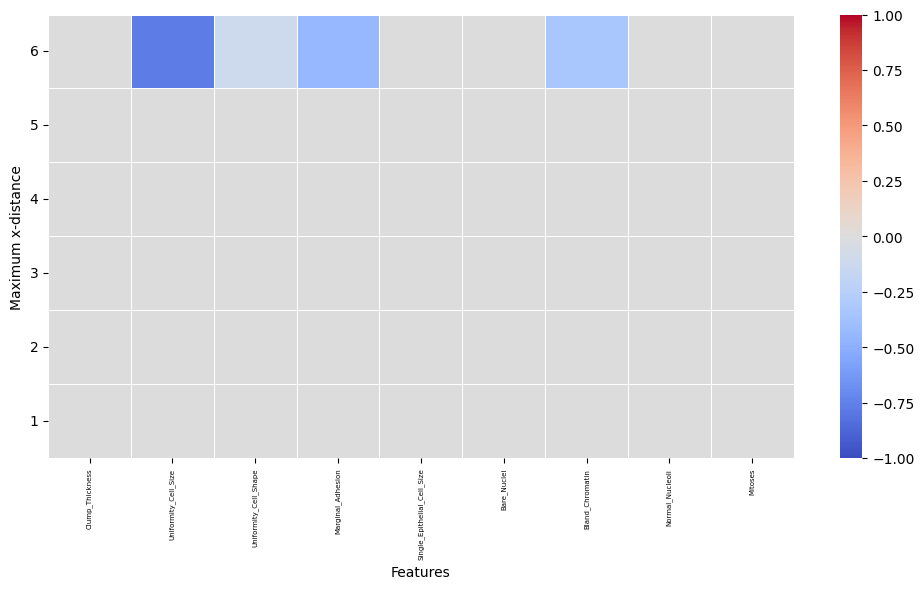

In [67]:
prueba.plot_heatmap(col_labels=col_names,epsList=[6,5,4,3,2,1],p=2,theta=0)

<h1>One hidden layer</h1>

In [3]:
from NNClassificationDRO import NNClassificationDRO
prueba = NNClassificationDRO(X,y)
prueba.fit()

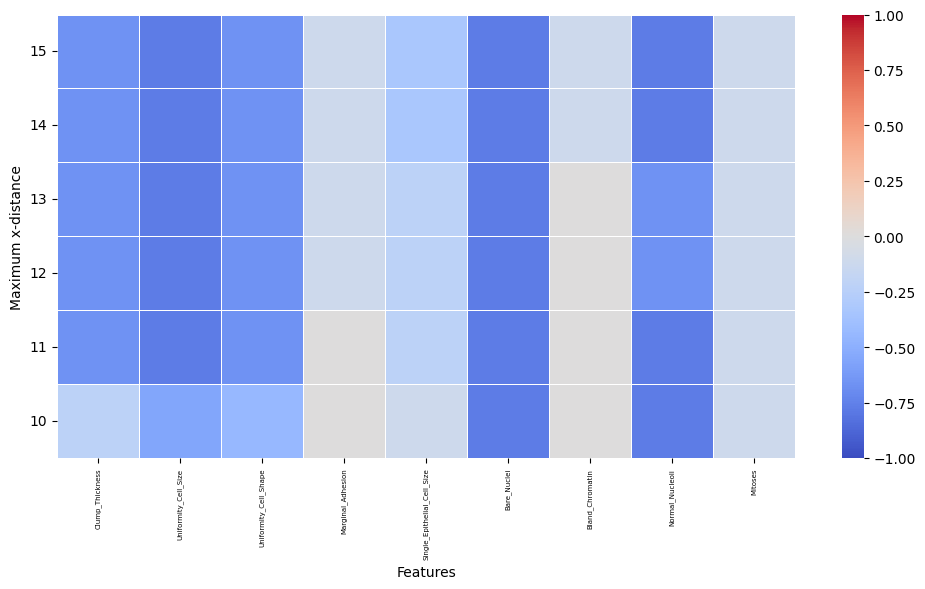

In [4]:
prueba.plot_heatmap(col_names,p=1,theta=1,epsList=[15,14,13,12,11,10])

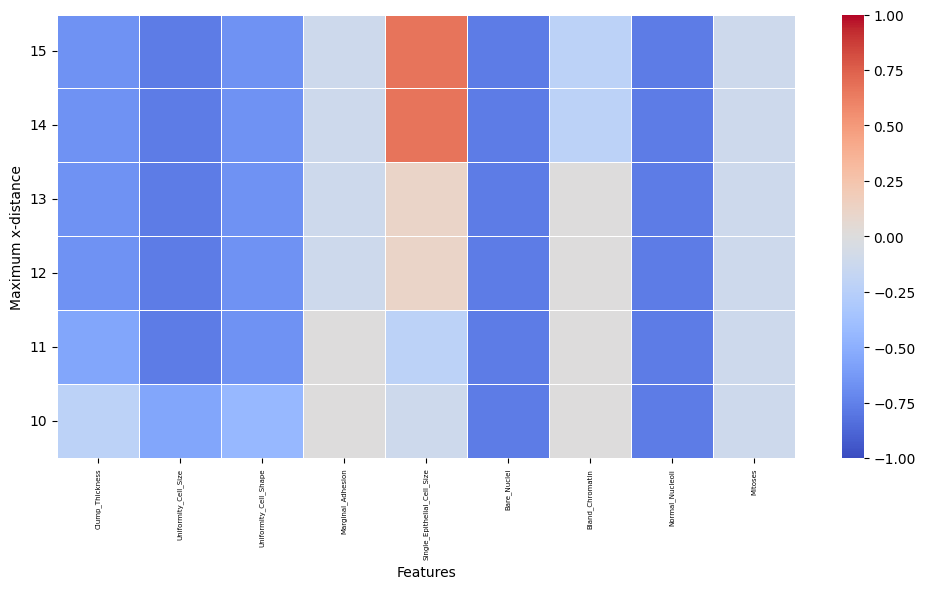

In [30]:
prueba.plot_heatmap(col_names,p=1,theta=0,epsList=[15,14,13,12,11,10])

100%|██████████| 5/5 [00:07<00:00,  1.51s/it]


PERCENTILES CALCULADOS


CALCULO DEL CONTRAFACTICO DE UN NUEVO INDIVIDUO


CALCULAMOS CON UN NUEVO EPSILON
CASO SIN INCERTIDUMBRE CALCULADO


CASO CON INCERTIDUMBRE CALCULADO
CALCULAMOS CON UN NUEVO EPSILON
CASO SIN INCERTIDUMBRE CALCULADO


...

CASO CON INCERTIDUMBRE CALCULADO
CALCULAMOS CON UN NUEVO EPSILON
CASO SIN INCERTIDUMBRE CALCULADO


CASO CON INCERTIDUMBRE CALCULADO
CALCULAMOS CON UN NUEVO EPSILON
CASO SIN INCERTIDUMBRE CALCULADO


CASO CON INCERTIDUMBRE CALCULADO
CALCULAMOS CON UN NUEVO EPSILON
CASO SIN INCERTIDUMBRE CALCULADO



100%|██████████| 5/5 [1:30:35<00:00, 1087.04s/it]

CASO CON INCERTIDUMBRE CALCULADO


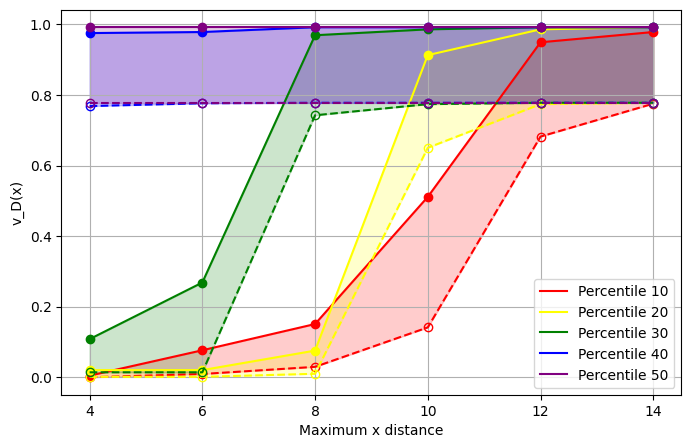

In [7]:
prueba.plotPareto(p=1,epsList=[4,6,8,10,12,14],highTheta=1)